<a href="https://www.kaggle.com/code/tokarserhii/dz-2026-01-21?scriptVersionId=294581575" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи +
На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader
Створити нейромережу:
використайте 3-5 шари
перший шар Flatten
кількість нейронів у шарах має не збільшуватись
використайте функції активації RELU або LeakyRELU
Збережіть kaggle notebook для подальшої роботи

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
all_dataset = datasets.ImageFolder(data_dir)

In [4]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
num_classes = len(all_dataset.classes)
num_classes

33

In [6]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.ToTensor()
    ]
)



In [7]:
len(all_dataset)

16854

In [8]:


data_train, data_test = torch.utils.data.random_split(all_dataset,[0.8, 0.2])


In [9]:
print(len(data_train), len(data_test), len(data_train) + len(data_test))

13484 3370 16854


In [10]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]
        new_img = self.transformer(img)
        return new_img, y

In [11]:
train_data = TransformDataset(data_train,train_transform)
test_data = TransformDataset(data_test,test_transform)
print(len(train_data), len(test_data))

13484 3370


In [12]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [13]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([42, 3, 224, 224])
torch.Size([42])


(224, 224, 3)


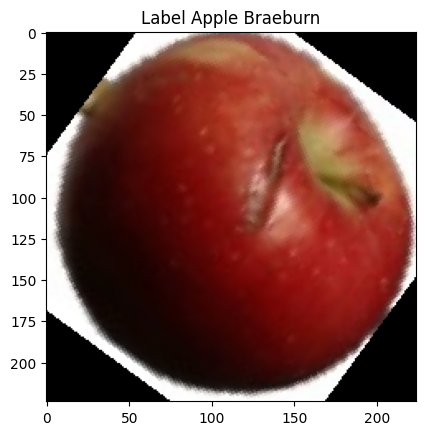

(224, 224, 3)


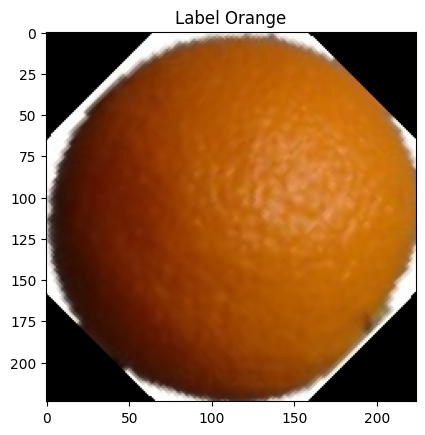

(224, 224, 3)


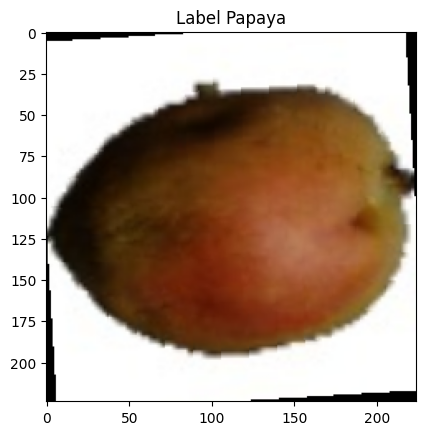

In [14]:


import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()



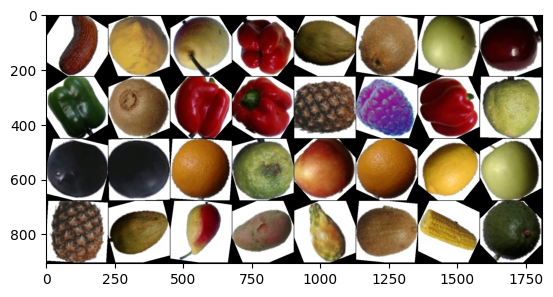

In [15]:
from torchvision.utils import make_grid
loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)
batch, labels = next(iter(loader))
grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор
plt.imshow(grid)

In [16]:
batch.shape

torch.Size([32, 3, 224, 224])

In [17]:
img, label = train_data[0]
img.shape

torch.Size([3, 224, 224])

In [18]:
3*224*224

150528

In [19]:
device = 'cuda'

In [20]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х224х224 в нейрони 150528
    nn.Linear(150528, 128),   # на вході 150528 нейронів передає інформацію 128 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes)  # 33 (!) нейрони на кожен фрукт
    
)


# підключення до процесора
model = model.to(device)
img = img.to(device)
# print(img.shape)
img = img.unsqueeze(0)
model(img)


tensor([[ 0.0967,  0.1195, -0.0432, -0.0881,  0.0294, -0.0377,  0.0357,  0.0951,
         -0.1490,  0.0754, -0.0429, -0.1459, -0.0852, -0.0764,  0.1586, -0.0567,
         -0.0430, -0.0009,  0.1149,  0.0264, -0.0812,  0.0638, -0.1389, -0.0624,
         -0.0401,  0.0911, -0.0020,  0.0028, -0.0828,  0.0938, -0.0260, -0.0245,
          0.0142]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [22]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нейромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 0.33835768699645996
loss: 7.390140533447266
loss: 1.5626435279846191
loss: 2.335010051727295
loss: 3.3859658241271973
loss: 1.9289793968200684
loss: 0.9297956228256226
loss: 1.2131381034851074
loss: 1.492035150527954
loss: 1.5763620138168335
loss: 1.5998997688293457
loss: 0.8671784996986389
loss: 0.7901371717453003
loss: 0.9101192951202393
loss: 0.8765926957130432
loss: 1.0078957080841064
loss: 0.8379607200622559
loss: 0.8066678643226624
loss: 0.5900478363037109
loss: 0.5235287547111511
loss: 0.5176757574081421
loss: 0.6847572922706604
loss: 0.6000238656997681
loss: 0.4814571142196655
loss: 0.5997302532196045
loss: 0.5945711135864258
loss: 0.4696614146232605
loss: 0.46690303087234497
loss: 0.45468589663505554
loss: 0.43301019072532654
loss: 0.42957139015197754
loss: 0.37985891103744507
loss: 0.4072123169898987
loss: 0.4558592140674591
loss: 0.362421452999115
loss: 0.3098904490470886
loss: 0.3883982300758362
loss: 0.4414701461791992
loss: 0.40378081798553467
loss: 0.32893276214599

In [25]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(torch.softmax(prediction, dim=1))

0
tensor([[8.6227e-01, 6.5828e-17, 1.3776e-09, 2.0975e-09, 2.1336e-16, 1.0128e-26,
         3.6870e-10, 5.5501e-25, 2.1558e-08, 2.1019e-13, 4.0298e-18, 5.6099e-15,
         5.1609e-18, 3.8060e-08, 1.6250e-22, 4.5316e-27, 8.6700e-25, 1.9636e-16,
         6.9549e-15, 2.3679e-08, 1.7929e-17, 1.1269e-02, 1.1472e-12, 1.2362e-24,
         1.5059e-05, 6.3071e-08, 1.2125e-04, 1.2633e-01, 7.2077e-19, 3.0410e-23,
         7.6673e-07, 4.8529e-09, 3.0625e-24]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


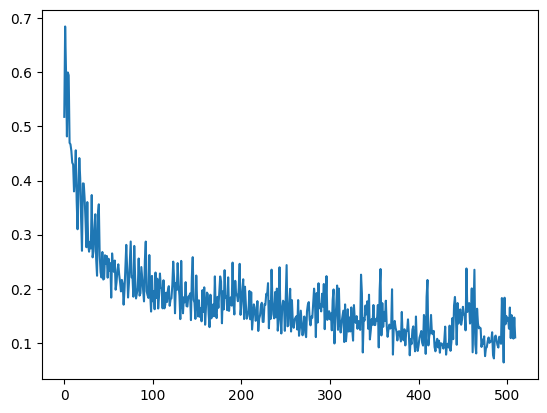

In [26]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)